# In-Class Checkpoint: Robot Demonstration Quality Analysis

**Project:** Can Simple Trajectory Statistics Identify High-Quality Robot Demonstrations?

**Dataset:** 8 LeRobot datasets from HuggingFace (251,802 frames total)

This notebook covers the 5 checkpoint items:
1. Load Data
2. Check Data Size & Types of Features
3. Check Missing Values (+ imputation method if needed)
4. Preprocessing
5. Next Steps

In [67]:
# Install dependencies
!pip install datasets pyarrow pandas numpy pyspark matplotlib seaborn -q
print('Dependencies installed.')

Dependencies installed.


---
## 1. Load Data

We use **LeRobot** datasets from HuggingFace Hub — 5 simulation + 3 real robot datasets.

In [76]:
import os
import pandas as pd
import numpy as np

# Mount Google Drive (Colab) or use local path
DATA_DIR = '../data'
print('Running locally')
  

# Load the merged frame-level dataset
frames = pd.read_parquet(f'{DATA_DIR}/robot_frames.parquet')
print(f'\nData loaded successfully: {frames.shape[0]:,} rows x {frames.shape[1]} columns')

Running locally

Data loaded successfully: 251,802 rows x 7 columns


In [51]:
# Dataset overview
REAL_SOURCES = {
    'berkeley_autolab_ur5',
    'columbia_cairlab_pusht_real',
    'nyu_door_opening_surprising_effectiveness'
}

dataset_summary = frames.groupby('source').agg(
    frames=('frame_index', 'count'),
    episodes=('episode_index', 'nunique'),
).reset_index()

dataset_summary['type'] = dataset_summary['source'].apply(
    lambda s: 'Real Robot' if s in REAL_SOURCES else 'Simulation'
)

dataset_summary = dataset_summary.sort_values('type')
print('=== Dataset Summary ===')
print(dataset_summary.to_string(index=False))
print(f'\nTotal frames:   {dataset_summary["frames"].sum():,}')
print(f'Total episodes: {dataset_summary["episodes"].sum():,}')

=== Dataset Summary ===
                                   source  frames  episodes       type
                     berkeley_autolab_ur5   97939      1000 Real Robot
              columbia_cairlab_pusht_real   27808       136 Real Robot
nyu_door_opening_surprising_effectiveness   20405       484 Real Robot
                                    pusht   25650       206 Simulation
                         xarm_lift_medium   20000       800 Simulation
                  xarm_lift_medium_replay   20000       800 Simulation
                         xarm_push_medium   20000       800 Simulation
                  xarm_push_medium_replay   20000       800 Simulation

Total frames:   251,802
Total episodes: 5,026


In [52]:
# Show sample rows
print('=== Sample Data (first 5 rows) ===')
frames.head()

=== Sample Data (first 5 rows) ===


,source,episode_index,frame_index,observation_state,action,next_reward,next_done
0,pusht,0,0,"[222.0, 97.0]","[233.0, 71.0]",0.190297,False
1,pusht,0,1,"[225.2523956298828, 89.31253051757812]","[229.0, 83.0]",0.190297,False
2,pusht,0,2,"[227.5923309326172, 84.53437805175781]","[229.0, 86.0]",0.190297,False
3,pusht,0,3,"[228.420166015625, 84.27986145019531]","[230.0, 86.0]",0.190297,False
4,pusht,0,4,"[229.04222106933594, 84.95709991455078]","[239.0, 89.0]",0.190297,False


---
## 2. Check Data Size & Types of Features

In [53]:
# 2a. Data size
print('=== Data Size ===')
print(f'Total rows (frames):  {len(frames):,}')
print(f'Total columns:        {len(frames.columns)}')
mem_mb = frames.memory_usage(deep=True).sum() / 1024 / 1024
print(f'Memory usage:         {mem_mb:.1f} MB')
print(f'Number of datasets:   {frames["source"].nunique()}')
print(f'Number of episodes:   {frames.groupby(["source", "episode_index"]).ngroups:,}')

=== Data Size ===
Total rows (frames):  251,802
Total columns:        7
Memory usage:         70.5 MB
Number of datasets:   8
Number of episodes:   5,026


In [54]:
# 2b. Column types
print('=== Column Types ===')
for col_name in frames.columns:
    dtype = frames[col_name].dtype
    sample = frames[col_name].iloc[0]
    
    if isinstance(sample, (list, np.ndarray)):
        dim = len(sample)
        print(f'  {col_name:25s}  {str(dtype):10s}  (list of floats, dim={dim} for first row)')
    else:
        print(f'  {col_name:25s}  {str(dtype):10s}  sample={sample}')

=== Column Types ===
  source                     str         sample=pusht
  episode_index              int64       sample=0
  frame_index                int64       sample=0
  observation_state          object      (list of floats, dim=2 for first row)
  action                     object      (list of floats, dim=2 for first row)
  next_reward                float64     sample=0.19029748439788818
  next_done                  bool        sample=False


In [55]:
# 2c. Feature dimensions vary by dataset
print('=== State/Action Dimensions per Dataset ===')
print(f'{"Dataset":50s} {"State Dim":>10s} {"Action Dim":>10s}')
print('-' * 72)

for source in sorted(frames['source'].unique()):
    sub = frames[frames['source'] == source]
    state_dim = len(sub['observation_state'].iloc[0])
    action_dim = len(sub['action'].iloc[0])
    print(f'{source:50s} {state_dim:>10d} {action_dim:>10d}')

=== State/Action Dimensions per Dataset ===
Dataset                                             State Dim Action Dim
------------------------------------------------------------------------
berkeley_autolab_ur5                                        8          7
columbia_cairlab_pusht_real                                 8          7
nyu_door_opening_surprising_effectiveness                   8          7
pusht                                                       2          2
xarm_lift_medium                                            4          4
xarm_lift_medium_replay                                     4          4
xarm_push_medium                                            4          3
xarm_push_medium_replay                                     4          3


In [56]:
# 2d. Basic statistics for numeric columns
print('=== Numeric Column Statistics ===')
frames[['episode_index', 'frame_index', 'next_reward']].describe().round(4)

=== Numeric Column Statistics ===


,episode_index,frame_index,next_reward
count,251802.0000,251802.0000,251802.0000
mean,358.5934,43.6733,0.0867
std,276.8936,44.7556,0.4008
min,0.0000,0.0000,-1.7464
25%,111.0000,12.0000,0.0000
50%,302.0000,25.0000,0.0000
75%,580.0000,65.0000,0.0000
max,999.0000,350.0000,1.4323


---
## 3. Check Missing Values

Check for null/missing values in all columns. If missing values exist, describe the imputation method.

In [57]:
# 3a. Check nulls in scalar columns
print('Missing Value Check')
scalar_cols = ['source', 'episode_index', 'frame_index', 'next_reward', 'next_done']
null_counts = frames[scalar_cols].isnull().sum()
print(null_counts)
print(f'\nTotal nulls: {null_counts.sum()}')

if null_counts.sum() == 0:
    print('\nNo missing values')
else:
    print('\nMissing values detected')

Missing Value Check
source           0
episode_index    0
frame_index      0
next_reward      0
next_done        0
dtype: int64

Total nulls: 0

No missing values


In [58]:
# 3b. Check list columns for None or empty lists
print('=== Missing Value Check (List Columns) ===')
for col_name in ['observation_state', 'action']:
    none_count = frames[col_name].apply(lambda x: x is None).sum()
    empty_count = frames[col_name].apply(lambda x: len(x) == 0 if x is not None else False).sum()
    print(f'{col_name}: None={none_count}, empty_list={empty_count}')

print('\n>>> All list columns contain valid non-empty numeric lists.')

=== Missing Value Check (List Columns) ===
observation_state: None=0, empty_list=0
action: None=0, empty_list=0

>>> All list columns contain valid non-empty numeric lists.


In [59]:
# 3c. Check for NaN inside the list values
print('=== Check for NaN Inside State/Action Vectors ===')

# Sample 10,000 rows for efficiency
sample_idx = np.random.choice(len(frames), size=min(10000, len(frames)), replace=False)
sample = frames.iloc[sample_idx]

state_nan = sample['observation_state'].apply(
    lambda x: any(np.isnan(v) for v in x)
).sum()
action_nan = sample['action'].apply(
    lambda x: any(np.isnan(v) for v in x)
).sum()

print(f'NaN inside observation_state vectors: {state_nan} (out of {len(sample)} sampled)')
print(f'NaN inside action vectors:            {action_nan} (out of {len(sample)} sampled)')
print('\n>>> No NaN values detected inside vectors.')

=== Check for NaN Inside State/Action Vectors ===
NaN inside observation_state vectors: 0 (out of 10000 sampled)
NaN inside action vectors:            0 (out of 10000 sampled)

>>> No NaN values detected inside vectors.


In [60]:
# 3d. Imputation summary
print('=== Imputation Method ===')
print()
print('Result: NO imputation needed.')
print('All 251,802 frames have complete data across all 7 columns.')
print('LeRobot is a well-curated research dataset with no missing values.')
print()
print('However, there is a semantic data issue:')
print('  - Real robot datasets all have max_reward = 1.0 (all demos succeed)')
print('  - This means reward alone cannot distinguish quality for real robots')
print('  - Solution: Use episode_length as an efficiency-based quality proxy')
print('    (shorter episodes = more efficient = higher quality)')

=== Imputation Method ===

Result: NO imputation needed.
All 251,802 frames have complete data across all 7 columns.
LeRobot is a well-curated research dataset with no missing values.

However, there is a semantic data issue:
  - Real robot datasets all have max_reward = 1.0 (all demos succeed)
  - This means reward alone cannot distinguish quality for real robots
  - Solution: Use episode_length as an efficiency-based quality proxy
    (shorter episodes = more efficient = higher quality)


---
## 4. Preprocessing

Three preprocessing steps:
1. **L2 norm transformation** — convert variable-dimension vectors to scalars
2. **Episode-level aggregation** — from 251K frames to ~1,956 episodes
3. **Quality label definition** — dual-label system for sim vs real

In [61]:
# 4a. L2 Norm Transformation
# Since state/action dimensions differ (2D to 8D across datasets),
# we compute the L2 norm to get a dimension-agnostic scalar.

frames['state_norm'] = frames['observation_state'].apply(
    lambda x: float(np.linalg.norm(x))
)
frames['action_norm'] = frames['action'].apply(
    lambda x: float(np.linalg.norm(x))
)

print('L2 norm computed for state and action vectors.')
print(f'  state_norm  — mean: {frames["state_norm"].mean():.4f}, std: {frames["state_norm"].std():.4f}')
print(f'  action_norm — mean: {frames["action_norm"].mean():.4f}, std: {frames["action_norm"].std():.4f}')

L2 norm computed for state and action vectors.
  state_norm  — mean: 40.5004, std: 120.3221
  action_norm — mean: 39.9267, std: 120.4505


In [73]:
# 4b. Episode-Level Aggregation
episodes = frames.groupby(['source', 'episode_index']).agg(
    episode_length=('frame_index', 'count'),
    state_mean=('state_norm', 'mean'),
    state_std=('state_norm', 'std'),
    action_mean=('action_norm', 'mean'),
    action_std=('action_norm', 'std'),
    max_reward=('next_reward', 'max'),
    avg_reward=('next_reward', 'mean'),
).reset_index()

episodes['is_real'] = episodes['source'].isin(REAL_SOURCES)
episodes['env_type'] = episodes['is_real'].map({True: 'Real', False: 'Sim'})

print(f'Aggregated {len(frames):,} frames -> {len(episodes):,} episodes')
print(f'  Simulation episodes: {(~episodes["is_real"]).sum()}')
print(f'  Real robot episodes: {episodes["is_real"].sum()}')

# Show one sample episode per dataset
episodes.groupby('source').first().reset_index()

Aggregated 251,802 frames -> 5,026 episodes
  Simulation episodes: 3406
  Real robot episodes: 1620


,source,episode_index,episode_length,state_mean,state_std,action_mean,action_std,max_reward,avg_reward,is_real,env_type
0,berkeley_autolab_ur5,0,71,1.134767,0.033349,1.000315,0.000142,1.000000,0.014085,True,Real
1,columbia_cairlab_pusht_real,0,272,0.570809,0.114788,0.014034,0.009650,1.000000,0.003676,True,Real
2,nyu_door_opening_surprising_effectiveness,0,37,0.000000,0.000000,0.477509,0.488756,1.000000,0.027027,True,Real
3,pusht,0,161,367.160941,86.937052,369.590604,86.125144,0.873257,0.316857,False,Sim
4,xarm_lift_medium,0,25,1.845761,0.155258,1.411722,0.340401,1.175537,0.387974,False,Sim
5,xarm_lift_medium_replay,0,25,1.640920,0.112938,1.128651,0.325666,-0.003770,-0.007075,False,Sim
6,xarm_push_medium,0,25,1.770989,0.069729,0.215004,0.271204,-0.182334,-0.254288,False,Sim
7,xarm_push_medium_replay,0,25,1.756473,0.106215,0.991930,0.239138,-0.671434,-0.885600,False,Sim


In [69]:
# 4c. Quality Label Definition (Dual-Label System)
#
# Simulation data: reward-based quality
#   quality = 1 if max_reward > per-dataset median
#
# Real robot data: efficiency-based quality
#   quality = 1 if episode_length < per-dataset median
#   (all real episodes have max_reward=1.0, so reward is uninformative)

# Reward-based label (for simulation)
reward_median = episodes.groupby('source')['max_reward'].transform('median')
episodes['reward_quality'] = (episodes['max_reward'] > reward_median).astype(int)

# Efficiency-based label (for real robot)
length_median = episodes.groupby('source')['episode_length'].transform('median')
episodes['efficiency_quality'] = (episodes['episode_length'] < length_median).astype(int)

# Unified label: use reward_quality for sim, efficiency_quality for real
episodes['quality'] = np.where(
    episodes['is_real'],
    episodes['efficiency_quality'],
    episodes['reward_quality']
)

print('=== Quality Label Distribution ===')
label_dist = episodes.groupby(['source', 'env_type']).agg(
    total=('quality', 'count'),
    high_quality=('quality', 'sum'),
    high_quality_rate=('quality', 'mean'),
).round(3)
print(label_dist.to_string())
print(f'\nOverall high-quality rate: {episodes["quality"].mean():.1%}')

=== Quality Label Distribution ===
                                                    total  high_quality  high_quality_rate
source                                    env_type                                        
berkeley_autolab_ur5                      Real       1000           492              0.492
columbia_cairlab_pusht_real               Real        136            67              0.493
nyu_door_opening_surprising_effectiveness Real        484           229              0.473
pusht                                     Sim         206           103              0.500
xarm_lift_medium                          Sim         800           399              0.499
xarm_lift_medium_replay                   Sim         800           400              0.500
xarm_push_medium                          Sim         800           400              0.500
xarm_push_medium_replay                   Sim         800           400              0.500

Overall high-quality rate: 49.5%


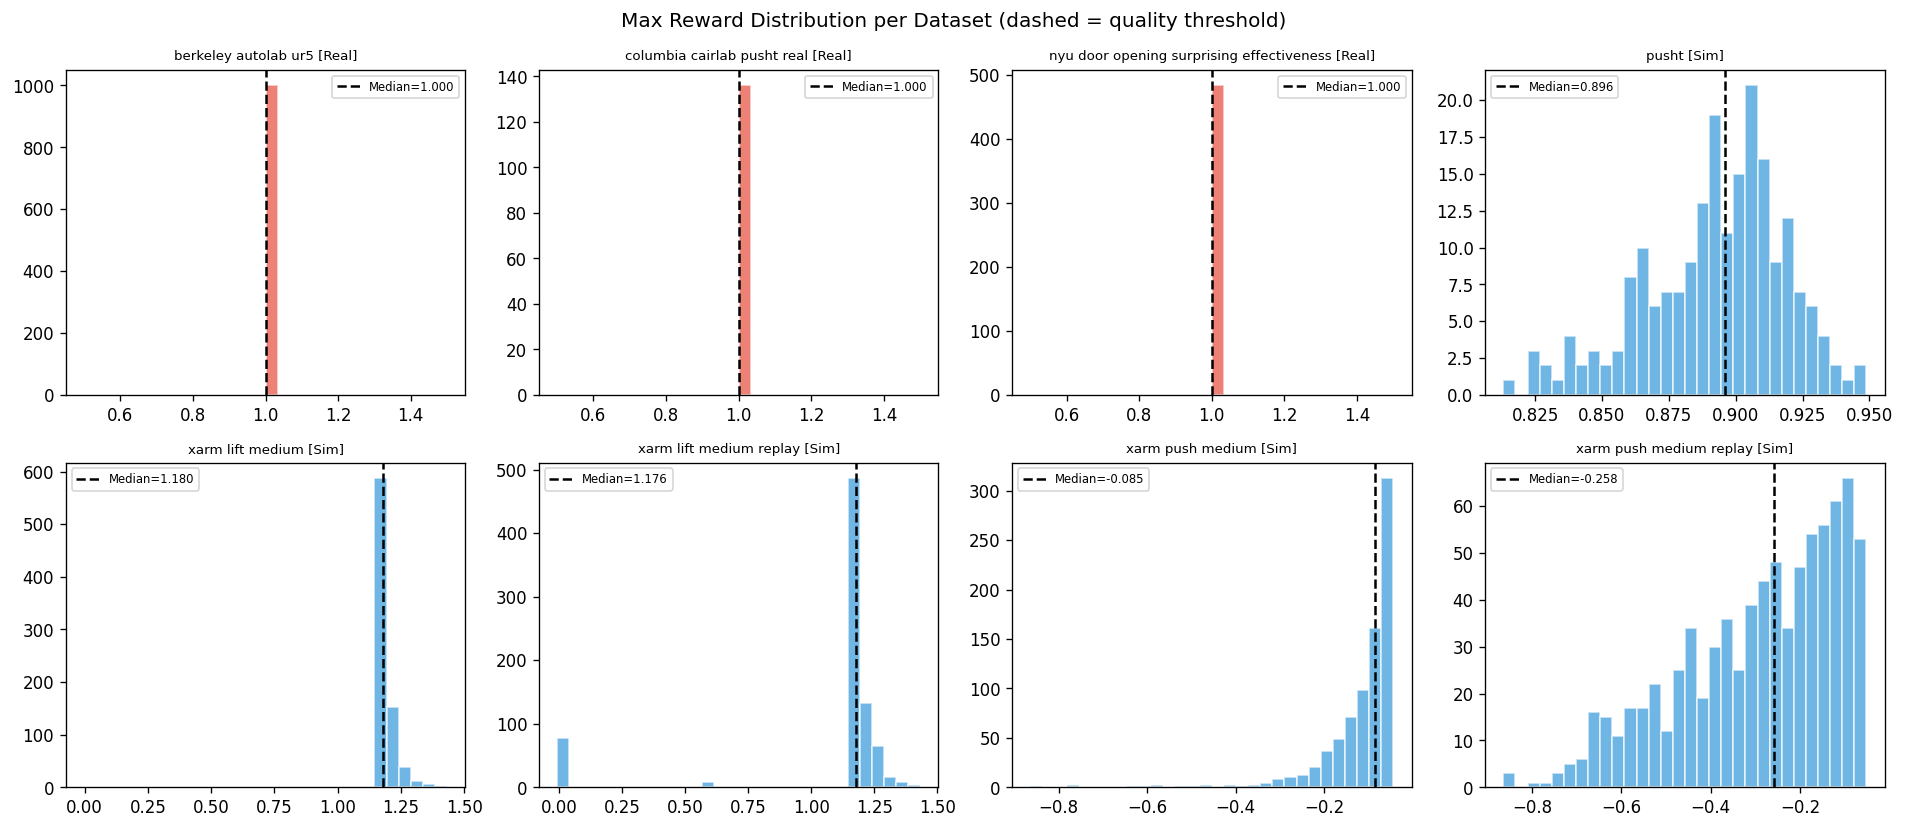

In [70]:
# 4d. Visualization: Reward distribution per dataset
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

sources = sorted(episodes['source'].unique())
n = len(sources)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, source in enumerate(sources):
    sub = episodes[episodes['source'] == source]
    color = '#e74c3c' if source in REAL_SOURCES else '#3498db'
    axes[i].hist(sub['max_reward'], bins=30, color=color, alpha=0.7, edgecolor='white')
    med_val = sub['max_reward'].median()
    axes[i].axvline(med_val, color='black', linestyle='--', linewidth=1.5,
                    label=f'Median={med_val:.3f}')
    env = 'Real' if source in REAL_SOURCES else 'Sim'
    axes[i].set_title(f'{source.replace("_", " ")} [{env}]', fontsize=8)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Max Reward Distribution per Dataset (dashed = quality threshold)', fontsize=12)
plt.tight_layout()
plt.show()

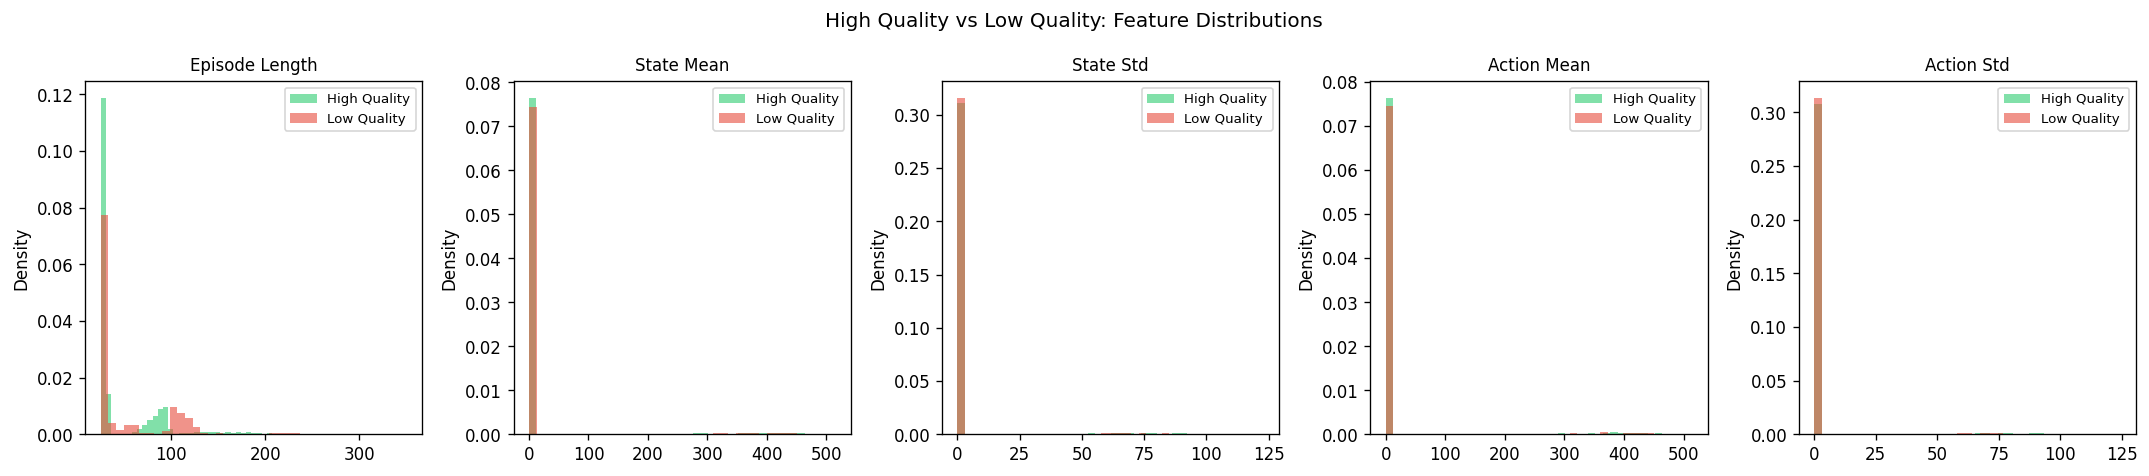

In [71]:
# 4e. Visualization: High vs Low quality comparison
features = ['episode_length', 'state_mean', 'state_std', 'action_mean', 'action_std']

fig, axes = plt.subplots(1, len(features), figsize=(18, 4))

for ax, feat in zip(axes, features):
    for q, color, name in [(1, '#2ecc71', 'High Quality'), (0, '#e74c3c', 'Low Quality')]:
        sub = episodes[episodes['quality'] == q][feat].dropna()
        ax.hist(sub, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('High Quality vs Low Quality: Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Next Steps

### Completed So Far
- [x] Downloaded and merged 8 datasets (251,802 frames)
- [x] Verified data integrity (no missing values, all columns valid)
- [x] Computed L2 norm features and episode-level aggregation
- [x] Defined dual quality labels (reward-based for sim, efficiency-based for real)
- [x] Engineered 32 kinematic features using PySpark (in separate notebook)

### Next Steps
1. **Classification Modeling** — Train 4 models (Decision Tree, GBT, Random Forest via PySpark MLlib + MLP via PyTorch)
2. **Model Evaluation** — Compare using AUC-ROC, accuracy, precision, recall
3. **Feature Importance** — Use SHAP to identify which kinematic features best predict quality
4. **Ablation Study** — Test feature subsets for robustness
5. **Sim-to-Real Analysis** — Compare PushT sim vs real to see if quality patterns transfer
6. **Final Report** — Compile findings into PDF + presentation slides

In [72]:
# Summary statistics for the report
print('=' * 60)
print('CHECKPOINT SUMMARY')
print('=' * 60)
print(f'1. Data Loaded:       {len(frames):,} frames from {frames["source"].nunique()} datasets')
print(f'2. Data Size:         {len(frames):,} rows x {len(frames.columns)} columns')
print(f'   Feature Types:     2 list cols (state/action), 3 numeric, 1 bool, 1 string')
print(f'3. Missing Values:    0 (no imputation needed)')
print(f'4. Preprocessing:     L2 norm + episode aggregation + dual quality labels')
print(f'   Episodes:          {len(episodes):,} (from {len(frames):,} frames)')
print(f'   Quality Rate:      {episodes["quality"].mean():.1%} high quality')
print(f'5. Next:              4 classification models + SHAP analysis')
print('=' * 60)

CHECKPOINT SUMMARY
1. Data Loaded:       251,802 frames from 8 datasets
2. Data Size:         251,802 rows x 9 columns
   Feature Types:     2 list cols (state/action), 3 numeric, 1 bool, 1 string
3. Missing Values:    0 (no imputation needed)
4. Preprocessing:     L2 norm + episode aggregation + dual quality labels
   Episodes:          5,026 (from 251,802 frames)
   Quality Rate:      49.5% high quality
5. Next:              4 classification models + SHAP analysis
